# Importation des modules

In [3]:
import pandas as pd
import numpy as np
import os
import statsmodels
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

In [2]:
!pip install openpyxl
!pip install missingno
!pip install statsmodels


   ---------------------------------------- 0/2 [et-xmlfile]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [open


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.5 MB 7.7 MB/s eta 0:00:02
   ------------- -------------------------- 3.1/9.5 MB 9.0 MB/s eta 0:00:01
   -------------------- ------------------- 5.0/9.5 MB 9.2 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.5 MB 9.3 MB/s eta 0:00:01
   -------------------------------------- - 9.2/9.5 MB 9.5 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 9.4 MB/s  0:00:01

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   --------------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Chargement des données
diviser les dépenses de santé par le PIB pour les avoir en %  
rajouter les données de dépenses de santé pour 1994 - 2004 en regardant sur les données de l'ocde  
rajouter la base mortalite  
faire le tri dans les pays de la bdd nb de médecins  


In [23]:
depenses_sante_vol = pd.read_excel(os.path.join("data", "Depenses_sante_en_volume_fr.xlsx"))
depenses_sante_PIB = pd.read_excel(os.path.join("data", "Depenses_Sante_PIB_fr.xlsx"))
pib = pd.read_excel(os.path.join("data", "PIB_fr.xlsx"))
pib_par_habitant = pd.read_excel(os.path.join("data", "PIB_par_habitant_fr.xlsx"))
pop_tot = pd.read_excel(os.path.join("data", "Pop_tot_fr.xlsx"))
pop65 = pd.read_excel(os.path.join("data", "Pop+65ans_fr.xlsx"))
part_pop65 = pd.read_excel(os.path.join("data", "part_pop_plus_65_fr.xlsx"))
pop_par_age = pd.read_excel(os.path.join("data", "Population_par_age_tranches5ans_fr.xlsx"))
offre_medicale = pd.read_excel(os.path.join("data", "Offre-medicale_Practiciens.xlsx"))

In [5]:
offre_medicale

,TIME,1993,1994,1995,1996,1997,1998,1999,2000,2001,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Belgique,:,:,:,:,:,:,:,107.03,107.4,...,110.8,112.86,113.41,115.04,116.85,118.71,120.42,120.21,123.56,:
1,Tchéquie,:,:,67.37,:,:,:,:,70.1,:,...,:,:,:,:,68.69,67.13,71.82,77.19,76.37,:
2,Danemark,:,43.21,47.3,49.21,55.3,58.92,60.33,67.93,68.38,...,78.8,78.97,79.52,80.07,79.82,79.53,80.15,71.81,68.93,:
3,Allemagne,75.65,77.82,79.76,81.2,81.74,82.95,84.61,87.83,88.66,...,94.2,95.16,96.42,97.37,98.99,100.87,101.77,103.02,106.07,:
4,Estonie,:,:,:,:,:,60.31,71.56,79.11,68.92,...,79.41,80.09,79.94,82.8,83.05,81.53,86.86,87.63,88.23,:
5,Irlande,:,:,:,:,:,:,:,:,:,...,174.28,172.34,177.38,181.47,181.64,185.72,229.78,172.50,205.63,203.39
6,Grèce,:,:,:,:,:,:,:,:,:,...,40.99,42.16,43.37,40.93,44.14,44.58,46.81,45.79,46.97,:
7,Espagne,:,:,:,:,:,:,:,:,:,...,74.03,74.16,75.4,88.93,91.54,91.43,94.35,95.13,94.76,:
8,France,141.77,143.19,143.74,144.13,143.93,144.22,143.57,145.91,147.8,...,139.35,139.46,140.25,139.9,140.15,139.05,138.02,137.23,139.08,:
9,Italie,:,:,:,:,:,:,:,80.63,81.75,...,89.62,90.38,89.76,88.6,87.99,84.72,109.39,104.89,100.42,:


# Construction du Time-to-Death

In [5]:
def time_to_death(mortalite, pop) :
    # pour pop, à voir si on prend pop_tot, pop_65 ou une population plus âgée encore
    # ou faire une somme pondérée des mortalités pour les 65-70, 70-75, etc
    # fait par chatgpt, à revoir en fonction de la structure des données
    df = mortalite.merge(
        pop_tot,
        on=["country", "year", "age"],
        how="inner"
    )

    df["weighted_mortality"] = df["mortality_rate"] * df["population"]
    ttd = (
        df.groupby(["country", "year"])["weighted_mortality"]
          .sum()
          .reset_index(name="TTD")
    )
    return ttd

#pop = pop_65   # ou pop_80, ou pop_tot...
#ttd = time_to_death(mortalite, pop)

# Mise en forme du panel

In [24]:
def preparer_donnees(fichier, var) :   #var est un str indiquant le nom de la variable, comme "PIB" ou "depenses"
    df = fichier.copy()
    df = df.replace(':', np.nan)
    df = pd.melt(df, id_vars=['TIME'], var_name='Year', value_name=var)
    df = df.rename(columns={'TIME': 'Country'})
    df['Year'] = df['Year'].astype(int)  # S'assurer que l'année est un entier
    df = df.set_index(['Country', 'Year']).sort_index()
    return df

In [25]:
panel_depenses_sante_PIB = preparer_donnees(depenses_sante_PIB, "Depenses de sante en % du PIB")
panel_PIB_par_habitant = preparer_donnees(pib_par_habitant, "PIB par habitant")
panel = pd.merge(panel_depenses_sante_PIB, panel_PIB_par_habitant, on=['Country', 'Year'], how='outer')
panel_pop65 = preparer_donnees(part_pop65, "Part des +65 ans")
panel = pd.merge(panel, panel_pop65, on=['Country', 'Year'], how='outer')
panel_offre_medicale = preparer_donnees(offre_medicale, "Densité médicale")
panel = pd.merge(panel, panel_offre_medicale, on=['Country', 'Year'], how='outer')
panel['Depenses t-1'] = panel.groupby(level='Country')['Depenses de sante en % du PIB'].shift(1)

# 3. Structuration en Panel (MultiIndex)
#panel = panel.set_index(['Country', 'Year']).sort_index()
panel.loc['Portugal']

,Depenses de sante en % du PIB,PIB par habitant,Part des +65 ans,Densité médicale,Depenses t-1
Year,,,,,
1993,NaN,NaN,0.142398,163.41,NaN
1994,NaN,NaN,0.145039,156.61,NaN
1995,NaN,60.9,0.147758,146.44,NaN
1996,NaN,61.6,0.150645,144.86,NaN
1997,NaN,63.8,0.153210,144.46,NaN
1998,NaN,65.4,0.155996,145.93,NaN
1999,NaN,67.2,0.158368,150.08,NaN
2000,0.086010,67.8,0.160296,152.15,NaN
2001,0.086275,68.0,0.163408,156.62,0.086010


In [26]:
#panel_depenses_sante_PIB.to_excel("panel_depenses_sante_PIB.xlsx", index=False)
#panel_PIB_par_habitant.to_excel("panel_PIB_par_habitant.xlsx", index=False)
#panel_pop65.to_excel("panel_pop65.xlsx", index=False)
#panel = pd.merge(panel_depenses_sante_PIB, panel_PIB_par_habitant, on=['Country', 'Year'], how='outer')
panel.to_excel("panel.xlsx", index=False)

## Visualisation des valeurs manquantes

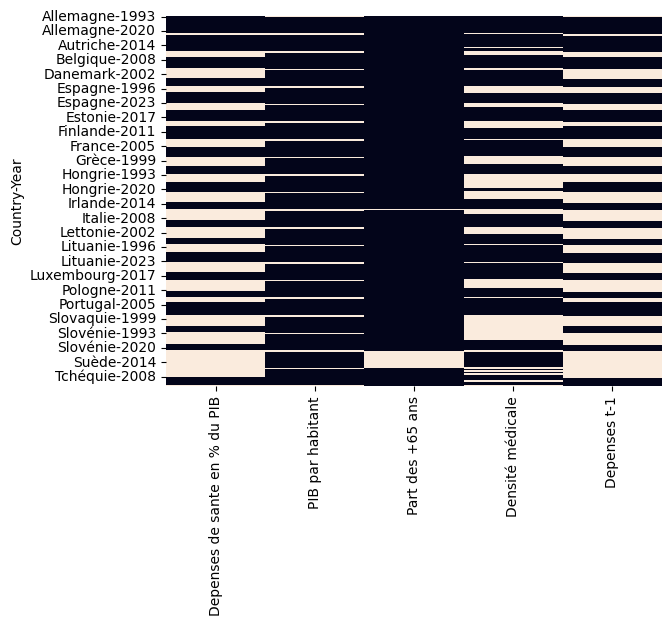

In [29]:
df = panel.copy()
sns.heatmap(df.isna(), cbar=False)
plt.show()

<Axes: >

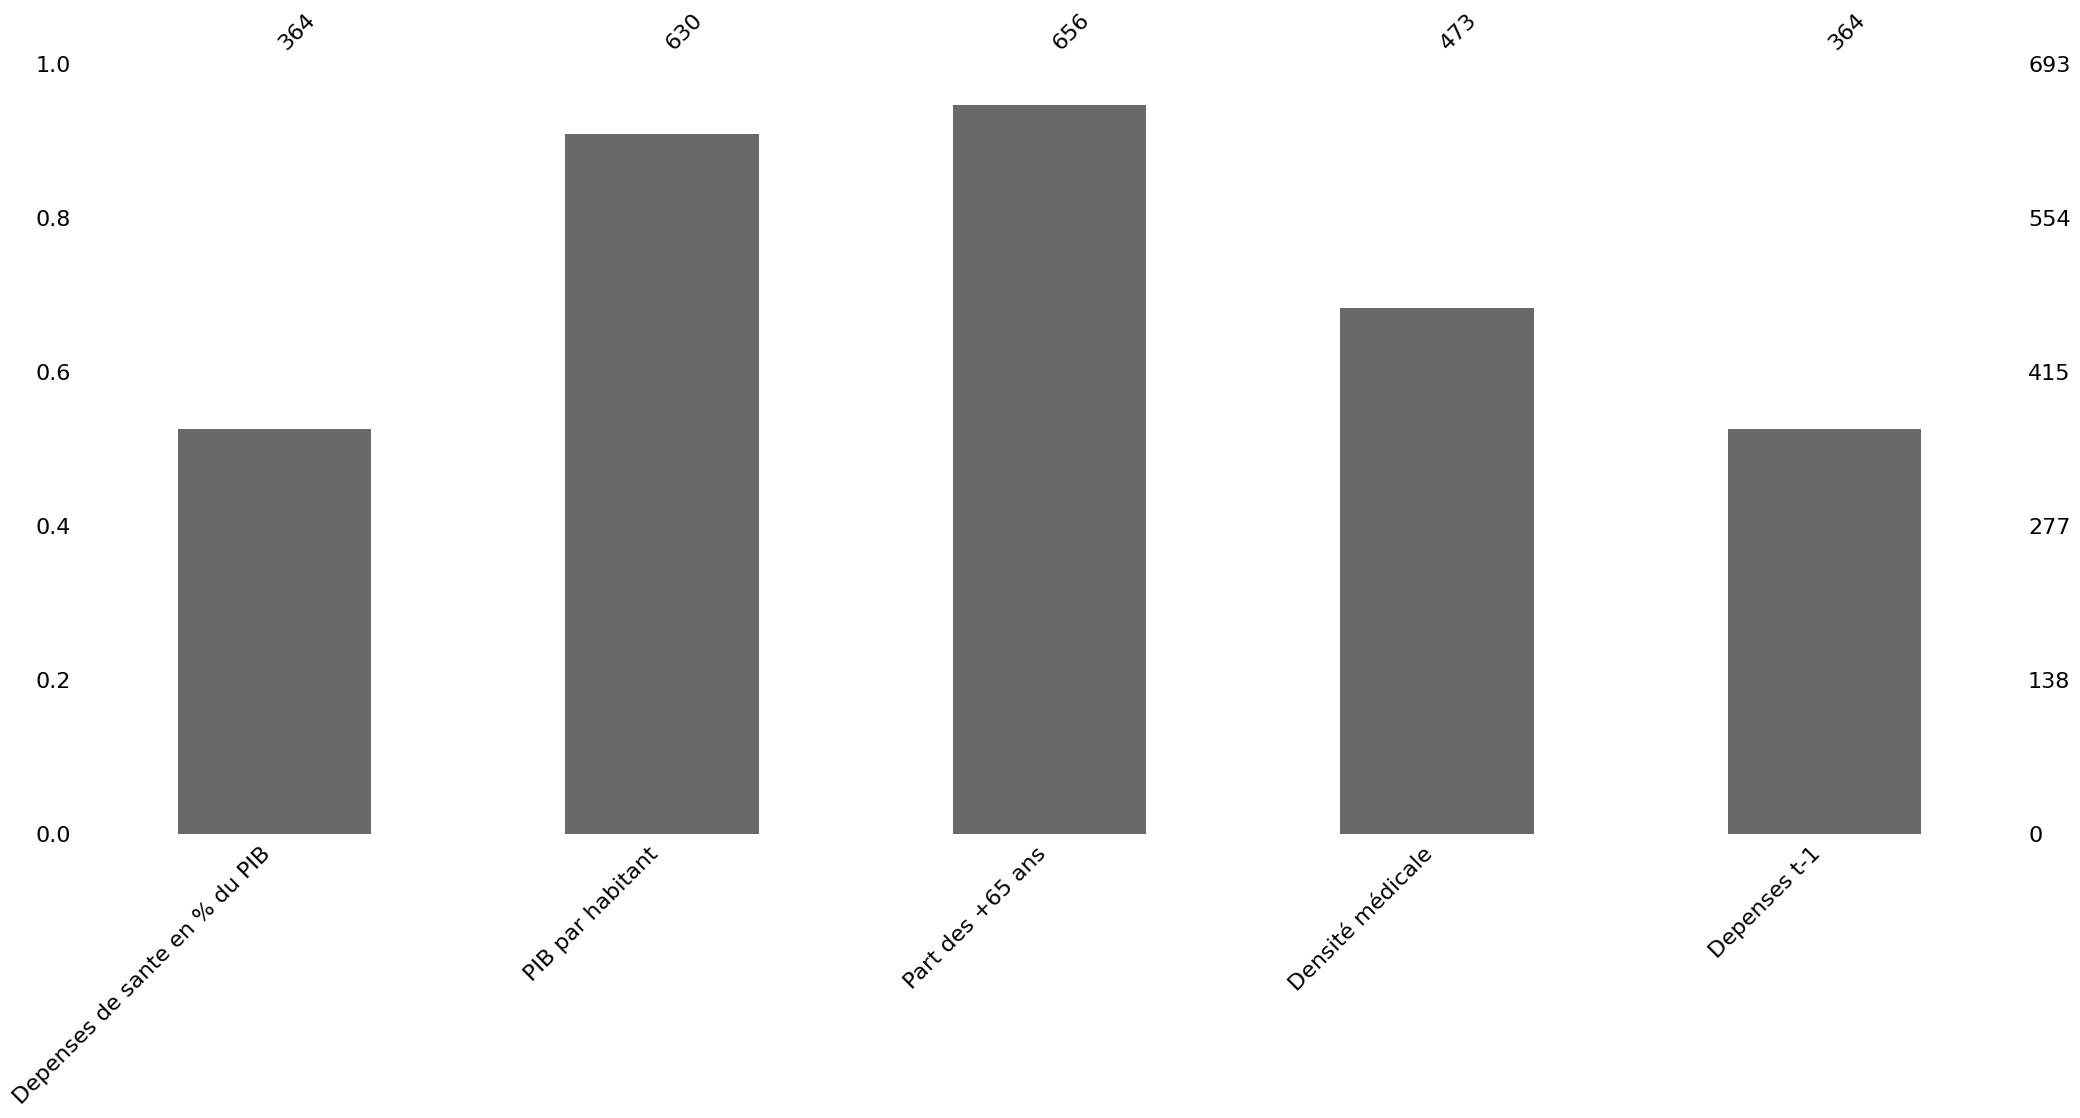

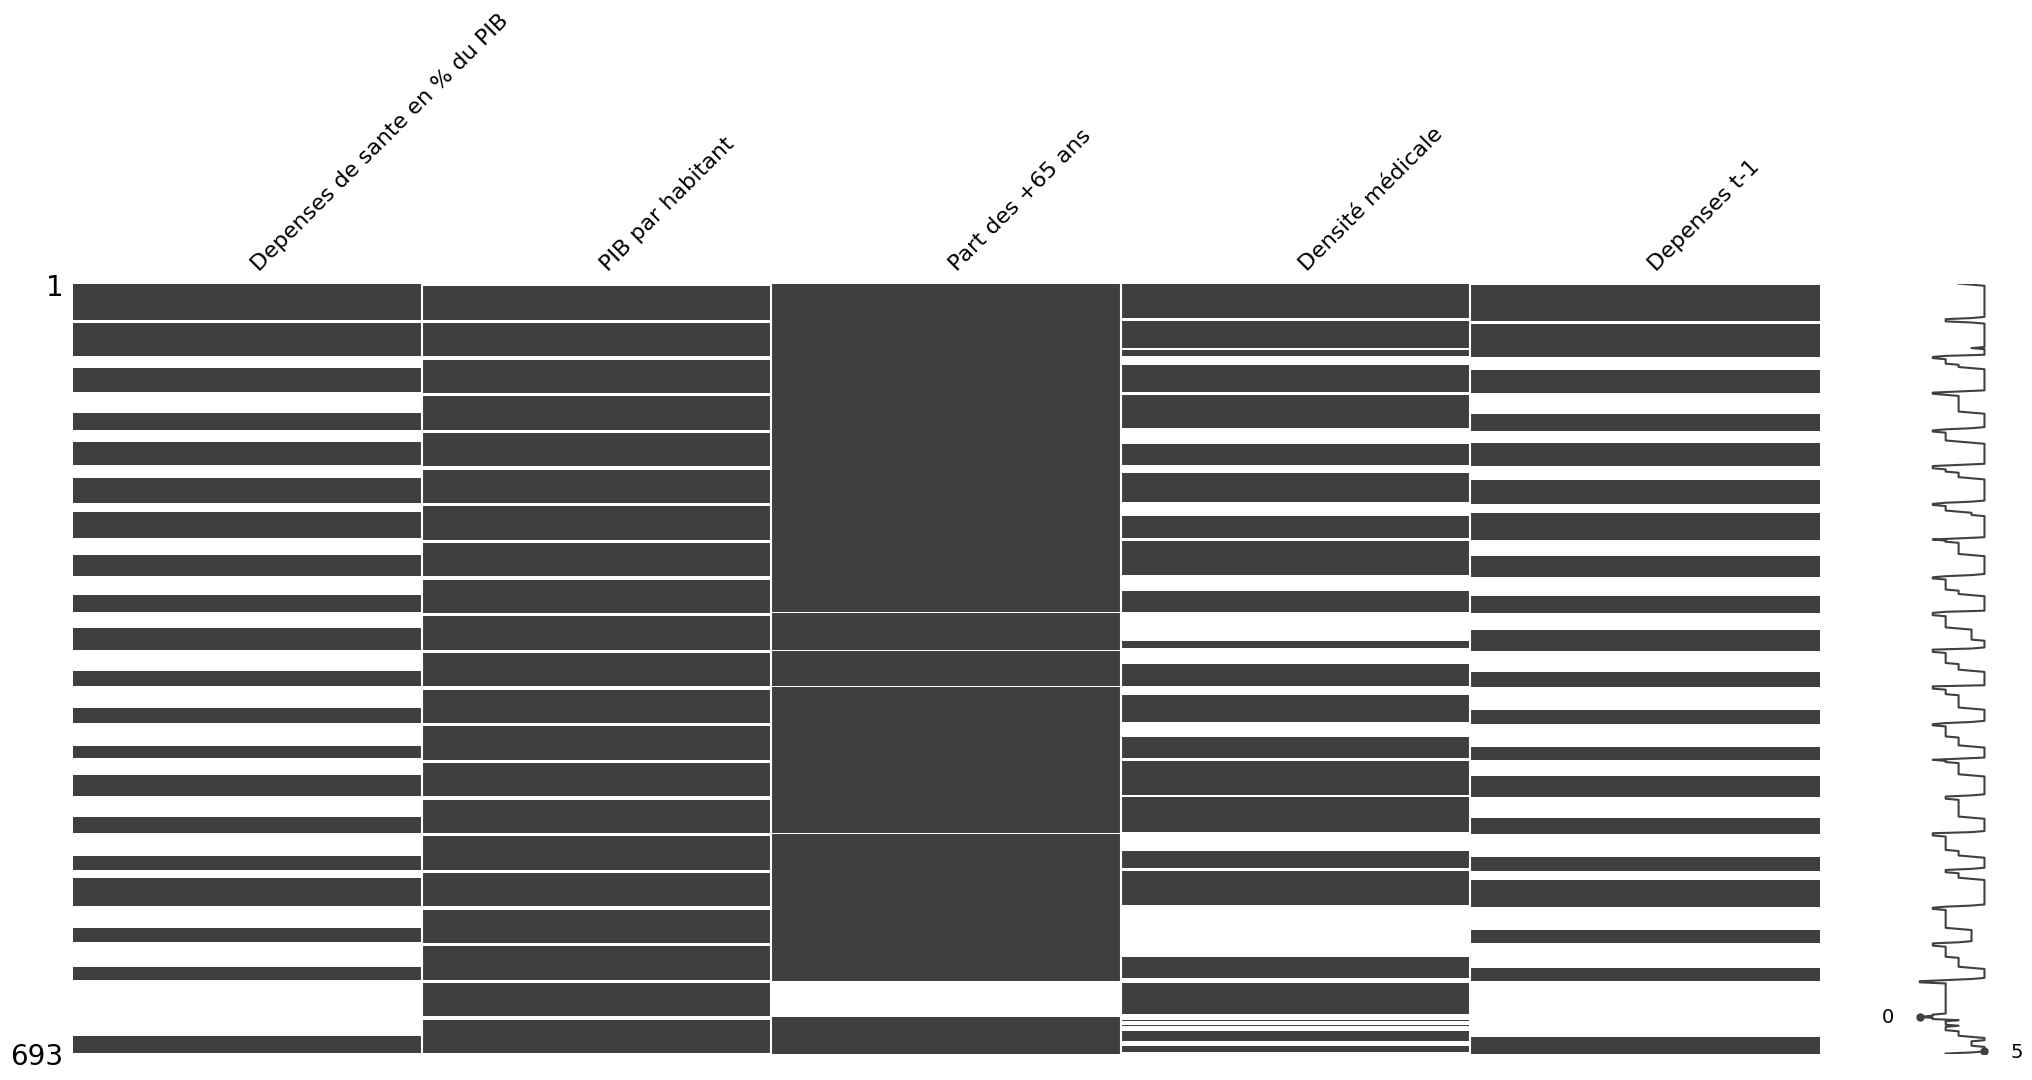

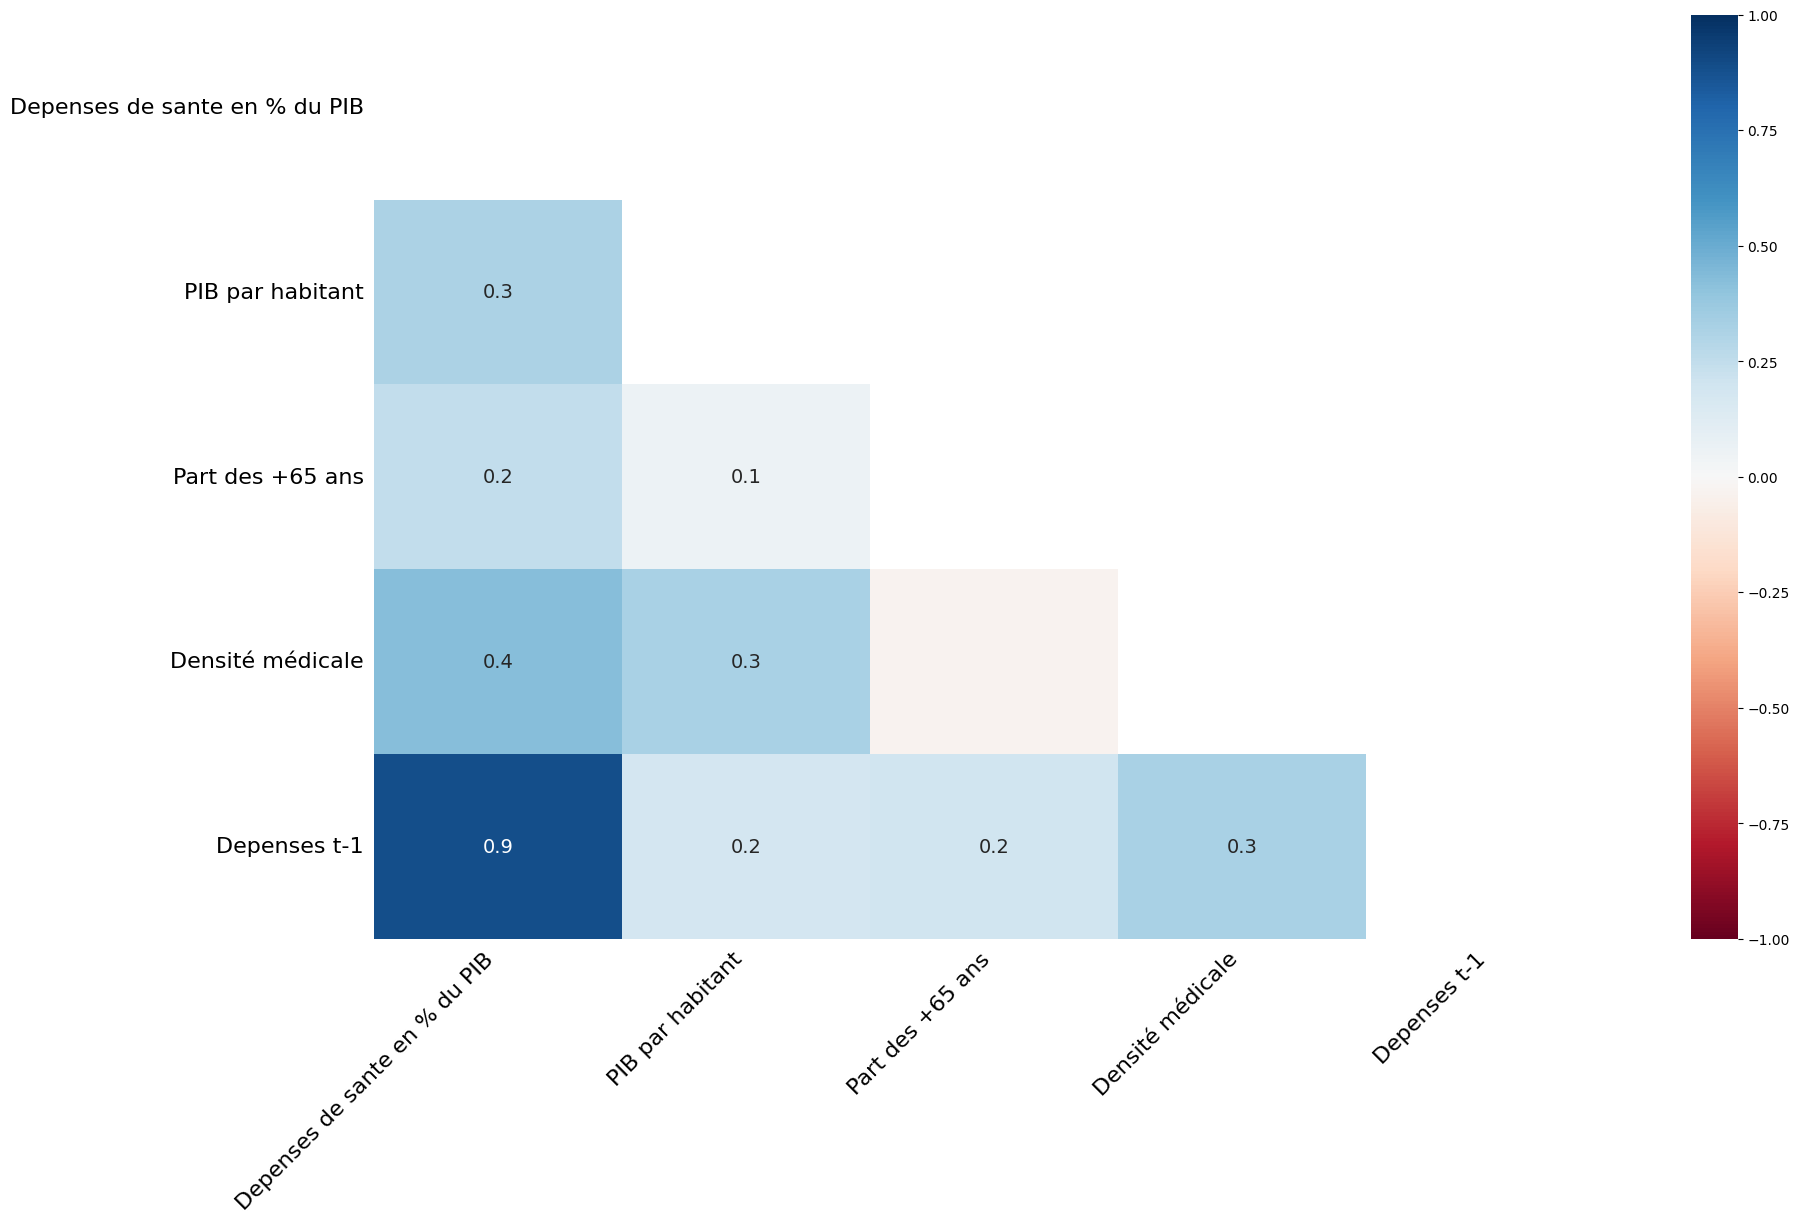

In [28]:
#visualisation des valeurs manquantes

df = panel.copy()
msno.bar(df)
msno.matrix(df)
msno.heatmap(df)

A value near -1 means if one variable appears then the other variable is very likely to be missing.  
A value near 0 means there is no dependence between the occurrence of missing values of two variables.  
A value near 1 means if one variable appears then the other variable is very likely to be present.  

In [11]:
missing_indicator = df.isna().astype(int)
corr = missing_indicator.corr()

print(corr)

                               Depenses de sante en % du PIB  \
Depenses de sante en % du PIB                       1.000000   
PIB par habitant                                   -0.415794   
Part des +65 ans                                    0.491253   
Densité médicale                                    0.644291   
Depenses t-1                                        0.920767   

                               PIB par habitant  Part des +65 ans  \
Depenses de sante en % du PIB         -0.415794          0.491253   
PIB par habitant                       1.000000         -0.744196   
Part des +65 ans                      -0.744196          1.000000   
Densité médicale                      -0.455841          0.529621   
Depenses t-1                          -0.426024          0.474188   

                               Densité médicale  Depenses t-1  
Depenses de sante en % du PIB          0.644291      0.920767  
PIB par habitant                      -0.455841     -0.426024  
Part des

In [11]:
import statsmodels.stats.missing
from statsmodels.stats.missing import test_missing_complete

test_missing_complete(df)

ModuleNotFoundError: No module named 'statsmodels.stats.missing'

In [31]:
print(len(panel['PIB par habitant']))
panel['PIB par habitant'].isnull().sum()

1299


np.int64(669)

## Données manquantes

In [25]:
#gérer les données manquantes
panel_transformed = panel.copy()

for col in panel.columns :
    panel_transformed[col] = df.groupby('Country')[col].transform(lambda x: x.fillna(x.median()))

/opt/python/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/python/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/python/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/python/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/python/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/python/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, ax

NameError: name 'penl_transformed' is not defined

In [26]:
panel_transformed

Depenses de sante en % du PIB  PIB par habitant  \
Country        Year                                                    
Allemagne      1993                       0.089399               NaN   
               1994                       0.091821               NaN   
               1995                       0.094900               NaN   
               1996                       0.097693               NaN   
               1997                       0.096631               NaN   
...                                            ...               ...   
United Kingdom 2021                       0.099038               NaN   
               2022                       0.099038               NaN   
               2023                       0.099038               NaN   
               2024                       0.099038               NaN   
               2025                       0.099038               NaN   

                     Part des +65 ans  Densité médicale  Depenses t-1  
Country        Year                                                    
Allemagne      1993               NaN             75.65      0.103735  
               1994               NaN             77.82      0.089399  
               1995               NaN             79.76      0.091821  
               1996               NaN             81.20      0.094900  
               1997               NaN             81.74      0.097693  
...                               ...               ...           ...  
United Kingdom 2021          0.159207               NaN      0.099038  
               2022          0.159207               NaN      0.099038  
               2023          0.159207               NaN      0.099038  
               2024          0.159207               NaN      0.099038  
               2025          0.159207               NaN      0.099038  

[1299 rows x 5 columns]

# Régression TTD  
On veut vérifier si contrôler par le TTD atténue l'impact du vieillissement sur les dépenses de santé.  
On fait notre régression sur plusieurs tranches d'âge au-dessus de 65 ans. Comme TTD, on utilise l'espérance de vie résiduelle de la tranche d'âge sur laquelle on se place et on remplace

# Régression et GMM